In [9]:
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs
import matplotlib.pyplot as plt

def merge_fits(files):
    wcs_list = []
    data_list = []
    
    # Load data and WCS from each file
    for file in files:
        with fits.open(file) as hdul:
            # Assuming the relevant image data is in the last two dimensions of a 4D array
            data = hdul[0].data
            header = hdul[0].header

            # Check data dimensions and slice accordingly
            if data.ndim == 4:
                # Take the first element in the first two dimensions to reduce to 2D
                data = data[0, 0, :, :]
            elif data.ndim != 2:
                raise ValueError(f"Unexpected data dimensions {data.shape}")

            # Update WCS to only include the spatial axes
            wcs = WCS(header).celestial
            
            data_list.append(data)
            wcs_list.append(wcs)
    
    # Determine the optimal WCS and shape
    wcs_out, shape_out = find_optimal_celestial_wcs(wcs_list)
    
    # Prepare arrays for combined data and weight map
    combined_data = np.zeros(shape_out)
    weight_map = np.zeros(shape_out)
    
    # Reproject each image to the optimal WCS and combine
    for data, wcs in zip(data_list, wcs_list):
        reprojected_data, footprint = reproject_interp((data, wcs), wcs_out, shape_out=shape_out)
        valid_mask = ~np.isnan(reprojected_data)
        
        combined_data[valid_mask] += reprojected_data[valid_mask]
        weight_map[valid_mask] += 1
    
    # Normalize combined data by the number of contributions in each pixel
    valid_weight_mask = weight_map > 0
    combined_data[valid_weight_mask] /= weight_map[valid_weight_mask]
    
    # Save the output image
    fits.writeto('combined.fits', combined_data, wcs_out.to_header(), overwrite=True)
    print("Combined image saved to 'combined.fits'.")

    # Optionally, show the image
    plt.figure(figsize=(10, 8))
    plt.imshow(combined_data, origin='lower', cmap='gray')
    plt.colorbar()
    plt.title('Combined Image')
    plt.show()

Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Combined image saved to 'combined.fits'.


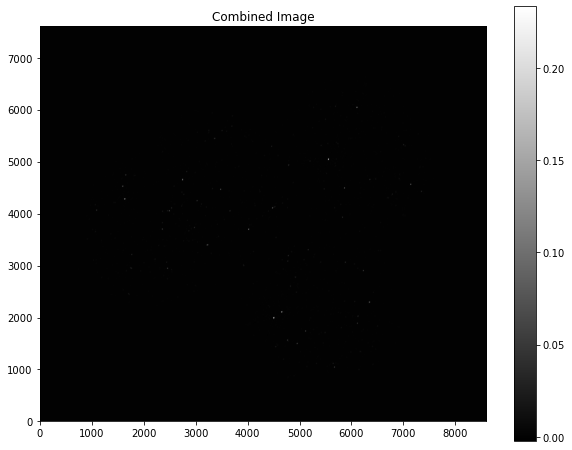

In [10]:
# Example usage
files = ['../server/source_detection/total/03:23:30.000001_+31.30.00.00000-mosaic-fieldALL-StokesI-2.5arc-5000-1e-4-spwALL-pb0.06-cyclenit500.image.fits', 
         '../server/source_detection/total/03:25:30.000000_+29.29.59.99999-mosaic-fieldALL-StokesI-2.5arc-5000-1e-4-spwALL-pb0.06-cyclenit500.image.fits', 
         '../server/source_detection/total/03:32:04.530001_+31.05.04.00000-mosaic-fieldALL-StokesI-2.5arc-5000-1e-4-spwALL-pb0.06-cyclenit500.image.fits',
         '../server/source_detection/total/03:36:00.000000_+30.30.00.00001-mosaic-fieldALL-StokesI-2.5arc-5000-1e-4-spwALL-pb0.06-cyclenit500.image.fits']  # List your FITS files here
merge_fits(files)

In [ ]:
x=